#Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import os
import random
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

#Load the dataset

In [ ]:
df = pd.read_excel("DataSetSW_ANN.xlsx")

In [ ]:
df.head()

,GDP,Population,GDP/Capita,Literacy Rate,Urban Population %,HH Size,Total_MSW_tons/year,MSW_tons/Capita/year,Organic%,Paper%,Plastic%,Metal%,Glass%,E waste %
0,3.917108e+10,2854191,13724.058594,99.0,65.000000,3.950000,1.087447e+06,0.381000,51.4,9.9,9.6,4.8,4.5,1.839171
1,4.802139e+11,40606052,11826.165039,81.4,75.000000,4.940000,1.237874e+07,0.304850,54.4,9.8,16.9,2.8,1.2,2.035748
2,6.178963e+08,55599,11113.442383,97.0,61.386364,4.182885,1.898949e+04,0.341544,19.7,26.4,12.8,7.9,3.4,0.000000
3,3.603207e+09,82431,43711.800781,100.0,88.000000,3.637898,4.300000e+04,0.521648,31.2,35.1,11.3,2.6,8.2,0.000000
4,2.016900e+11,25096150,8036.690430,72.0,64.500000,6.450000,4.213644e+06,0.167900,51.8,11.9,13.5,4.4,6.7,2.183384


#Correlation matrix

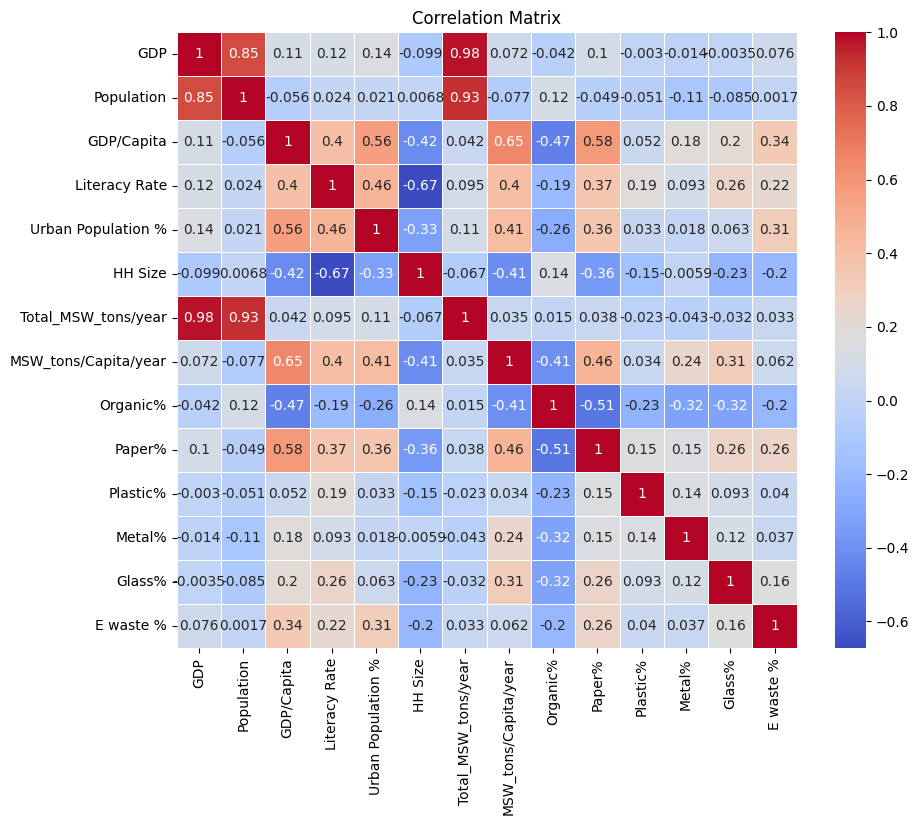

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

#Data Preprocessing

## Feature Selection

In [ ]:
target = "Total_MSW_tons/year"
# Exclude the target and compute absolute correlations with the target
feature_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False)
print("Feature correlations with target:")
print(feature_corr)
selected_features = ["GDP", "Population", "GDP/Capita", "Literacy Rate", "Urban Population %", "HH Size"]
# selected_features = ["GDP", "Population", "Urban Population %"]

# Create new DataFrame using the selected features
X = df[selected_features]
y = df[target]

Feature correlations with target:
GDP                     0.979209
Population              0.925509
Urban Population %      0.107518
Literacy Rate           0.095138
HH Size                 0.067467
Metal%                  0.043202
GDP/Capita              0.042331
Paper%                  0.037895
MSW_tons/Capita/year    0.035014
E waste %               0.033046
Glass%                  0.032370
Plastic%                0.022819
Organic%                0.015095
Name: Total_MSW_tons/year, dtype: float64


## Remove Outliers

In [ ]:
print("\nData shape before outlier removal (z-score):", X.shape)
def remove_outliers_z(X, y, threshold=3):
    # Combine features and target into one DataFrame for outlier removal
    data = pd.concat([X, y], axis=1)
    z_scores = np.abs(stats.zscore(data))
    # Filter out rows where any feature exceeds the threshold
    mask = (z_scores < threshold).all(axis=1)
    return data[mask].drop(columns=[y.name]), data[mask][y.name]

X, y = remove_outliers_z(X, y)
print("\nData shape after outlier removal (z-score):", X.shape)


Data shape before outlier removal (z-score): (161, 6)

Data shape after outlier removal (z-score): (151, 6)


## Train-test Split & Feature Scaling

In [ ]:
# Set seeds for reproducibility
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
# Reset Keras session
K.clear_session()
# Force deterministic operations
os.environ["TF_DETERMINISTIC_OPS"] = "1"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# # Scale targets separately
# y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
# y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


# Model Building

In [ ]:
# @tf.function(reduce_retracing=True)
def build_model(num_layers=1, neurons=6, activation='relu'):
    model = Sequential()
    # Input layer + first hidden layer
    model.add(Dense(neurons, activation=activation, input_shape=(X_train_scaled.shape[1],)))
    # Additional hidden layers (if any)
    for _ in range(num_layers - 1):
        model.add(Dense(neurons, activation=activation))
    # Output layer
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
param_grid = {
    'num_layers': [12],
    'neurons': [32],
    'activation': ['relu'] #, 'tanh', 'sigmoid']  # Add desired activation functions here
}

# param_grid = {
#     'num_layers': list(range(6, 13)),  # Layers from 2 to 12
#     'neurons': list(range(32, 513, 32)),  # Neurons from 32 to 512 with step 32
#     'activation': ['relu']
# }

best_score = -np.inf
best_params = {}
best_model = None

# Use a simple early stopping callback to avoid overfitting
early_stop = EarlyStopping(monitor='loss', patience=20, verbose=0)

# Loop over the grid including activation functions
for num_layers in param_grid['num_layers']:
    for neurons in param_grid['neurons']:
        for activation in param_grid['activation']:
            model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)
            history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=10, verbose=0, callbacks=[early_stop])

            y_pred = model.predict(X_test_scaled, verbose=0)
            score = r2_score(y_test, y_pred)

            print(f"Layers: {num_layers}, Neurons: {neurons}, Activation: {activation} -> Test R2: {score:.4f}" )

            if score > best_score:
                best_score = score
                best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
                best_model = model

print("\nBest Hyperparameters:", best_params)
print("Best Test R2 Score:", best_score)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 12, Neurons: 32, Activation: relu -> Test R2: 0.9112

Best Hyperparameters: {'num_layers': 12, 'neurons': 32, 'activation': 'relu'}
Best Test R2 Score: 0.9112086446722077


#Actual Vs Predicted Bar **Plot**

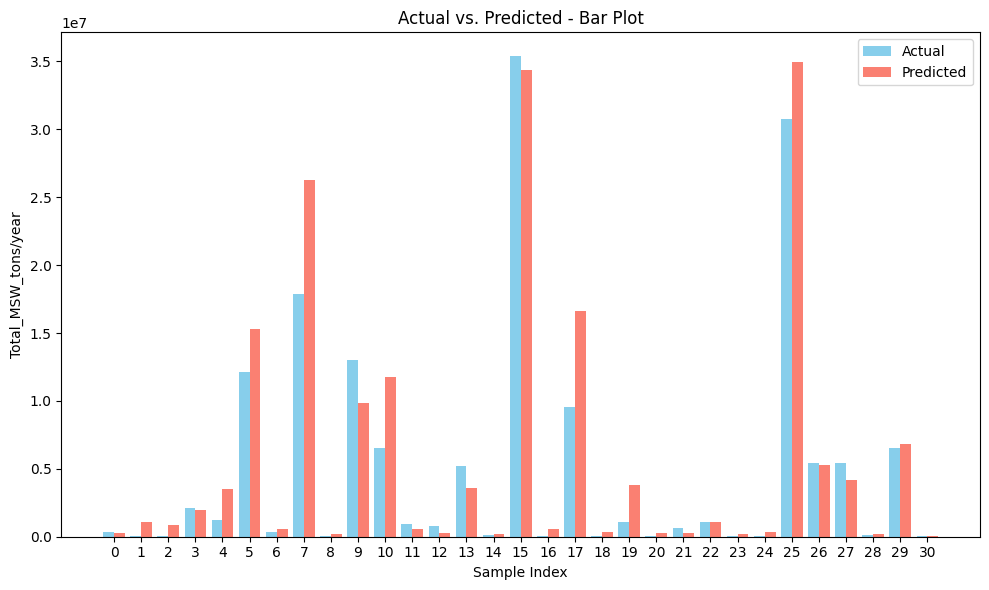

In [ ]:
# Predict the best model
y_pred_best = best_model.predict(X_test_scaled, verbose=0)

# Bar plot of Actual vs Predicted
plt.figure(figsize=(10, 6))
indices = np.arange(len(y_test))

plt.bar(indices - 0.2, y_test, width=0.4, label='Actual', color='skyblue')
plt.bar(indices + 0.2, y_pred_best.flatten(), width=0.4, label='Predicted', color='salmon')

plt.xlabel('Sample Index')
plt.ylabel('Total_MSW_tons/year')
plt.title('Actual vs. Predicted - Bar Plot')
plt.xticks(indices)
plt.legend()
plt.tight_layout()
plt.show()

#With all evaluation Parameters

Epoch 1: Train R²=-0.3128, Test R²=-0.3442
Epoch 2: Train R²=-0.3128, Test R²=-0.3442
Epoch 3: Train R²=-0.3128, Test R²=-0.3442
Epoch 4: Train R²=-0.3128, Test R²=-0.3442
Epoch 5: Train R²=-0.3128, Test R²=-0.3442
Epoch 6: Train R²=-0.3126, Test R²=-0.3440
Epoch 7: Train R²=-0.3116, Test R²=-0.3426
Epoch 8: Train R²=-0.3053, Test R²=-0.3343
Epoch 9: Train R²=-0.2707, Test R²=-0.2902
Epoch 10: Train R²=-0.1211, Test R²=-0.1174
Epoch 11: Train R²=0.2205, Test R²=0.0501
Epoch 12: Train R²=0.3757, Test R²=-0.2154
Epoch 13: Train R²=0.5265, Test R²=0.1634
Epoch 14: Train R²=0.6355, Test R²=0.3352
Epoch 15: Train R²=0.7182, Test R²=0.4290
Epoch 16: Train R²=0.7808, Test R²=0.5529
Epoch 17: Train R²=0.8253, Test R²=0.6500
Epoch 18: Train R²=0.8556, Test R²=0.7132
Epoch 19: Train R²=0.8764, Test R²=0.7623
Epoch 20: Train R²=0.8908, Test R²=0.7981
Epoch 21: Train R²=0.9007, Test R²=0.8224
Epoch 22: Train R²=0.9077, Test R²=0.8407
Epoch 23: Train R²=0.9128, Test R²=0.8549
Epoch 24: Train R²=0.9

<ipython-input-16-3e7872dc989a>:76: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  test_mape = mean_absolute_percentage_error(y_test.ravel(), y_pred.ravel())


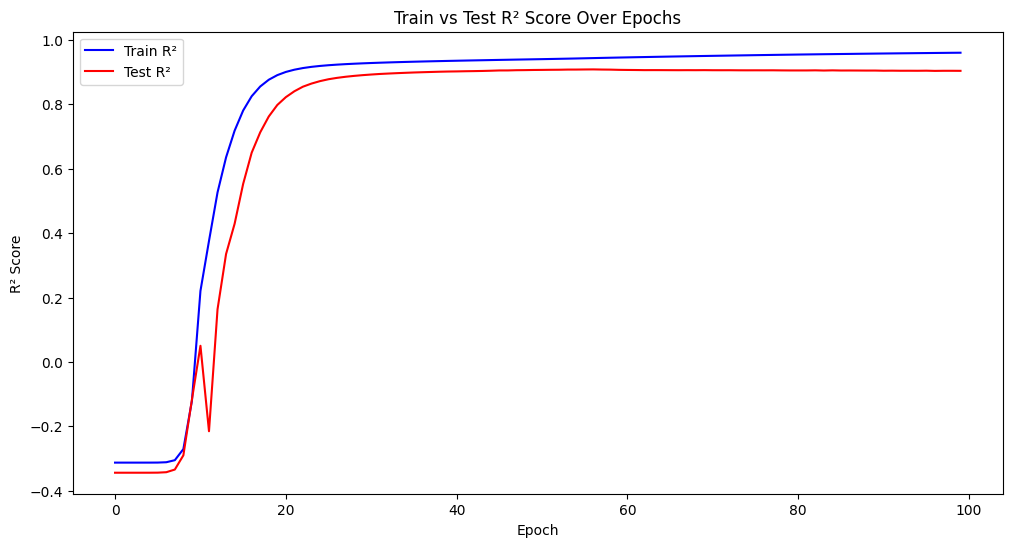


Best Hyperparameters: {'num_layers': 12, 'neurons': 32, 'activation': 'relu'}
Best Test R² Score: 0.9041


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def build_model(num_layers, neurons, activation):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))  # Use Input layer
    for _ in range(num_layers):
        model.add(Dense(neurons, activation=activation))
    model.add(Dense(1))  # Output layer
    model.compile(optimizer='adam', loss='mse')
    return model

# Custom callback to compute Train & Test R² at each epoch
class R2Callback(Callback):
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = np.ravel(y_train)  # Ensure 1D array
        self.X_test = X_test
        self.y_test = np.ravel(y_test)  # Ensure 1D array
        self.train_r2_scores = []
        self.test_r2_scores = []

    def on_epoch_end(self, epoch, logs=None):
        # Train predictions
        y_train_pred = self.model.predict(self.X_train, verbose=0)
        train_r2 = r2_score(self.y_train, y_train_pred)

        # Test predictions
        y_test_pred = self.model.predict(self.X_test, verbose=0)
        test_r2 = r2_score(self.y_test, y_test_pred)

        self.train_r2_scores.append(train_r2)
        self.test_r2_scores.append(test_r2)

        print(f"Epoch {epoch+1}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")

# Define parameter grid
param_grid = {'num_layers': [12], 'neurons': [32], 'activation': ['relu']}

best_score = -np.inf
best_params = {}
best_model = None
best_train_r2 = None
best_test_r2 = None

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='loss', patience=5, verbose=0)

# Iterate through hyperparameters
for num_layers in param_grid['num_layers']:
    for neurons in param_grid['neurons']:
        for activation in param_grid['activation']:

            model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)
            r2_callback = R2Callback(X_train_scaled, y_train, X_test_scaled, y_test)

            # Train model with callbacks
            history = model.fit(X_train_scaled, np.ravel(y_train), epochs=100, batch_size=10,
                                verbose=0, callbacks=[early_stop, r2_callback])

            # Final Test evaluation
            y_pred = model.predict(X_test_scaled, verbose=0)
            y_test = y_test.reshape(-1, 1) if len(y_test.shape) > 1 else y_test
            y_pred = y_pred.reshape(-1, 1) if len(y_pred.shape) > 1 else y_pred

            test_r2 = r2_score(y_test, y_pred)
            test_mae = mean_absolute_error(y_test, y_pred)
            test_mape = mean_absolute_percentage_error(y_test.ravel(), y_pred.ravel())
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            print(f"Layers: {num_layers}, Neurons: {neurons}, Activation: {activation} -> "
                  f"Test R²={test_r2:.4f}, MAE={test_mae:.2E}, MAPE={test_mape:.2f}, RMSE={test_rmse:.2E}")

            # Store best model
            if test_r2 > best_score:
                best_score = test_r2
                best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
                best_model = model
                best_train_r2 = r2_callback.train_r2_scores
                best_test_r2 = r2_callback.test_r2_scores

# Plot Train vs. Test R² over epochs for the best model
plt.figure(figsize=(12, 6))
plt.plot(best_train_r2, label="Train R²", color='blue')
plt.plot(best_test_r2, label="Test R²", color='red')
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Train vs Test R² Score Over Epochs")
plt.legend()
plt.show()

print("\nBest Hyperparameters:", best_params)
print(f"Best Test R² Score: {best_score:.4f}")


###Normalized Error Matrices

Epoch 1: Train R²=-0.3128, Test R²=-0.3442
Epoch 2: Train R²=-0.3128, Test R²=-0.3442
Epoch 3: Train R²=-0.3128, Test R²=-0.3442
Epoch 4: Train R²=-0.3128, Test R²=-0.3442
Epoch 5: Train R²=-0.3128, Test R²=-0.3442
Epoch 6: Train R²=-0.3127, Test R²=-0.3441
Epoch 7: Train R²=-0.3123, Test R²=-0.3436
Epoch 8: Train R²=-0.3097, Test R²=-0.3404
Epoch 9: Train R²=-0.2960, Test R²=-0.3234
Epoch 10: Train R²=-0.2317, Test R²=-0.2455
Epoch 11: Train R²=0.0028, Test R²=0.0093
Epoch 12: Train R²=0.3964, Test R²=0.1583
Epoch 13: Train R²=0.5135, Test R²=0.0542
Epoch 14: Train R²=0.6375, Test R²=0.4028
Epoch 15: Train R²=0.7178, Test R²=0.5234
Epoch 16: Train R²=0.7768, Test R²=0.5977
Epoch 17: Train R²=0.8225, Test R²=0.6898
Epoch 18: Train R²=0.8556, Test R²=0.7557
Epoch 19: Train R²=0.8794, Test R²=0.7997
Epoch 20: Train R²=0.8963, Test R²=0.8345
Epoch 21: Train R²=0.9080, Test R²=0.8602
Epoch 22: Train R²=0.9160, Test R²=0.8786
Epoch 23: Train R²=0.9215, Test R²=0.8916
Epoch 24: Train R²=0.92

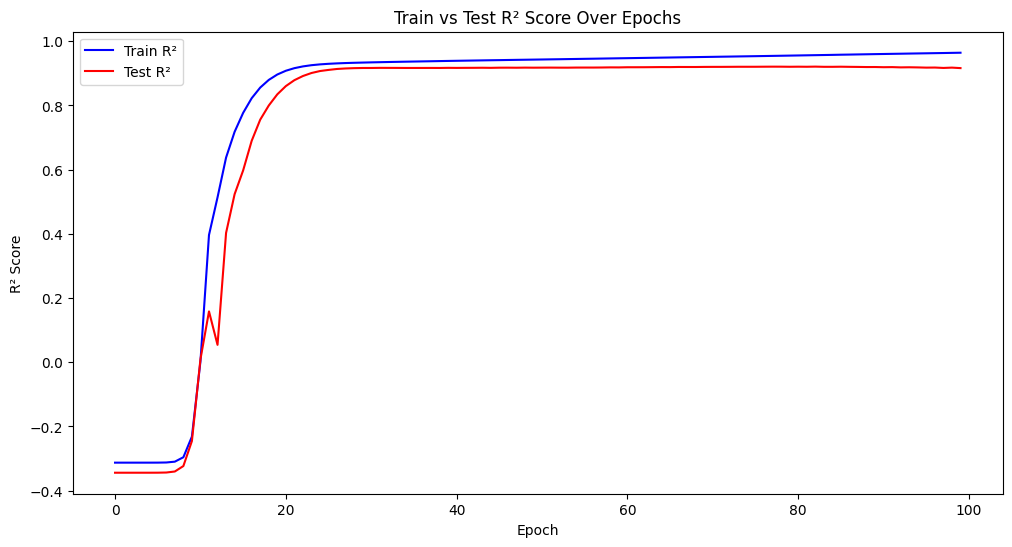


Best Hyperparameters: {'num_layers': 12, 'neurons': 32, 'activation': 'relu'}
Best Test R² Score: 0.9162


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-7))) * 100  # Avoid div by 0

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    return 100 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-7))

def build_model(num_layers, neurons, activation):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))
    for _ in range(num_layers):
        model.add(Dense(neurons, activation=activation))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

class R2Callback(Callback):
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = np.ravel(y_train)
        self.X_test = X_test
        self.y_test = np.ravel(y_test)
        self.train_r2_scores = []
        self.test_r2_scores = []

    def on_epoch_end(self, epoch, logs=None):
        y_train_pred = self.model.predict(self.X_train, verbose=0)
        y_test_pred = self.model.predict(self.X_test, verbose=0)

        train_r2 = r2_score(self.y_train, y_train_pred)
        test_r2 = r2_score(self.y_test, y_test_pred)

        self.train_r2_scores.append(train_r2)
        self.test_r2_scores.append(test_r2)

        print(f"Epoch {epoch+1}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")

# Define parameter grid
param_grid = {'num_layers': [12], 'neurons': [32], 'activation': ['relu']}

best_score = -np.inf
best_params = {}
best_model = None
best_train_r2 = None
best_test_r2 = None

early_stop = EarlyStopping(monitor='loss', patience=5, verbose=0)

for num_layers in param_grid['num_layers']:
    for neurons in param_grid['neurons']:
        for activation in param_grid['activation']:

            model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)
            r2_callback = R2Callback(X_train_scaled, y_train, X_test_scaled, y_test)

            history = model.fit(X_train_scaled, np.ravel(y_train), epochs=100, batch_size=10,
                                verbose=0, callbacks=[early_stop, r2_callback])

            y_pred = model.predict(X_test_scaled, verbose=0).ravel()
            y_true = np.ravel(y_test)

            test_r2 = r2_score(y_true, y_pred)
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mape = mean_absolute_percentage_error(y_true, y_pred)
            smape = symmetric_mean_absolute_percentage_error(y_true, y_pred)
            nrmse = rmse / np.mean(np.abs(y_true))
            nmae = mae / np.mean(np.abs(y_true))

            print(f"Layers: {num_layers}, Neurons: {neurons}, Activation: {activation} -> "
                  f"Test R²={test_r2:.4f}, MAE={mae:.2E}, NMAE={nmae:.4f}, "
                  f"RMSE={rmse:.2E}, NRMSE={nrmse:.4f}, MAPE={mape:.2f}%, SMAPE={smape:.2f}%")

            if test_r2 > best_score:
                best_score = test_r2
                best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
                best_model = model
                best_train_r2 = r2_callback.train_r2_scores
                best_test_r2 = r2_callback.test_r2_scores

# Plot Train vs. Test R² over epochs for the best model
plt.figure(figsize=(12, 6))
plt.plot(best_train_r2, label="Train R²", color='blue')
plt.plot(best_test_r2, label="Test R²", color='red')
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Train vs Test R² Score Over Epochs")
plt.legend()
plt.show()

print("\nBest Hyperparameters:", best_params)
print(f"Best Test R² Score: {best_score:.4f}")
